## RL PROJECT
Erfan Bateni 400100792
Amirali Jafari 400100938

In [2]:
!pip install gymnasium


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for gymnasium from https://files.pythonhosted.org/packages/56/d3/ea5f088e3638dbab12e5c20d6559d5b3bdaeaa1f2af74e526e6815836285/gymnasium-1.2.3-py3-none-any.whl.metadata
  Obtaining dependency information for farama-notifications>=0.0.1 from https://files.pythonhosted.org/packages/05/2c/ffc08c54c05cdce6fbed2aeebc46348dbe180c6d2c541c7af7ba0aa5f5f8/Farama_Notifications-0.0.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 10.2/952.1 kB ? eta -:--:--
   ---------------------------------------- 10.2/952.1 kB ? eta -:--:--
   ---------------------------------------- 10.2/952.1 kB ? eta -:--:--
   ---------------------------------------- 10.2/952.1 kB ? eta -:--:--
   ---------------------------------------- 10.2/952.1 kB

In [2]:
!pip install pygame

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pygame from https://files.pythonhosted.org/packages/d2/55/ca3eb851aeef4f6f2e98a360c201f0d00bd1ba2eb98e2c7850d80aabc526/pygame-2.6.1-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB 660.6 kB/s eta 0:00:17
   ---------------------------------------- 0.0/10.6 MB 330.3 kB/s eta 0:00:33
   ---------------------------------------- 0.1/10.6 MB 438.9 kB/s eta 0:00:25
   ---------------------------------------- 0.1/10.6 MB 438.9 kB/s eta 0:00:25
   ---------------------------------------- 0.1/10.6 MB 516.7 kB/s eta 0:00:21
    --------------------------------------- 0.1/10.6 MB 532.5 kB/s eta 0:00:20
    --------------------------------------- 0.2/10.6 MB 562.0 kB/s eta 0:00:19
    -------------------

In [10]:
import math
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import RecordVideo
import pygame
from IPython.display import Video

In [8]:
# reacher_env.py
class ReacherEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self, dt=0.02, target=None, render_mode=None, tau_max=2.0, max_steps=150, seed=None):
        super().__init__()
        self.l1 = 1.0
        self.l2 = 1.0
        self.m1 = 1.0
        self.m2 = 1.0
        self.b1 = 0.05
        self.b2 = 0.05
        self.dt = float(dt)
        self.tau_max = float(tau_max)
        self.max_steps = int(max_steps)
        self.render_mode = render_mode
        self.rng = np.random.default_rng(seed) 
        self.action_space = spaces.Box(
            low=-self.tau_max, high=self.tau_max, shape=(2,), dtype=np.float32
        ) 
        obs_low = np.array([-2.0, -2.0, -math.pi, -math.pi, -10.0, -10.0], dtype=np.float32)
        obs_high = np.array([ 2.0,  2.0,  math.pi,  math.pi,  10.0,  10.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.fixed_target = None if target is None else np.array(target, dtype=np.float64)
        self.q = np.zeros(2, dtype=np.float64)
        self.q_d = np.zeros(2, dtype=np.float64)
        self.target = np.zeros(2, dtype=np.float64)
        self.step_count = 0
        self._W = 600
        self._H = 600
        self.pygame = None
        self.screen = None
        self.clock = None


    def kinematics(self, q):
        theta_1, theta_2 = q
        x = self.l1 * math.cos(theta_1) + self.l2 * math.cos(theta_1 + theta_2)
        y = self.l1 * math.sin(theta_1) + self.l2 * math.sin(theta_1 + theta_2)
        return np.array([x, y], dtype=np.float64)

    def CT_dynamics(self, q, q_d):
        theta_1, theta_2 = q
        theta_d_1, theta_d_2 = q_d

        a = self.m1 * self.l1**2 + self.m2 * (self.l1**2 + self.l2**2)
        b = self.m2 * self.l1 * self.l2
        d = self.m2 * self.l2**2

        c2 = math.cos(theta_d_2)
        s2 = math.sin(theta_d_2)

        M = np.array([
            [a + 2 * b * c2, d + b * c2],
            [d + b * c2,       d]
        ], dtype=np.float64)

        Cq_d = np.array([
            -b * s2 * (2 * theta_d_1 * theta_d_2 + theta_d_2 ** 2),
             b * s2 * (theta_d_1 ** 2)
        ], dtype=np.float64)

        Bq_d = np.array([self.b1 * theta_d_1, self.b2 * theta_d_2], dtype=np.float64)

        return M, Cq_d, Bq_d

    def discrete(self, tau):
        M, Cq_d, Bq_d = self.CT_dynamics(self.q, self.q_d)
        q_dd = np.linalg.solve(M, tau - Cq_d - Bq_d) 
        self.q_d = self.q_d + q_dd * self.dt
        self.q = self.q + self.q_d * self.dt

    def observation(self):
        return np.array([self.target[0], self.target[1], self.q[0], self.q[1], self.q_d[0], self.q_d[1]], dtype=np.float32)

    def info(self):
        p_end = self.kinematics(self.q)
        err = p_end - self.target
        loss = err[0] ** 2 + err[1] ** 2
        return {"p_end": p_end, "target": self.target.copy(), "loss": loss}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.step_count = 0
        self.q = self.rng.uniform(low=-0.5, high=0.5, size=(2,))
        self.q_d = self.rng.uniform(low=-0.1, high=0.1, size=(2,))

        if self.fixed_target is not None:
            self.target = self.fixed_target.copy()
        else:
            for _ in range(1000):
                t = self.rng.uniform(low=-1.8, high=1.8, size=(2,))
                if np.linalg.norm(t) <= (self.l1 + self.l2) and np.linalg.norm(t) >= 0.2:
                    self.target = t
                    break

        obs = self.observation()
        info = self.info()
        if self.render_mode == "human":
            self.render()
        return obs, info

    def step(self, action):
        action = np.asarray(action, dtype=np.float64).reshape(2,)
        tau = np.clip(action, -self.tau_max, self.tau_max)
        self.discrete(tau)
        info = self.info()
        reward = -info["loss"]
        self.step_count += 1
        terminated = False  
        if self.step_count >= self.max_steps:
            truncated = 1
        else:
            truncated = 0
        obs = self.observation()

        if self.render_mode == "human":
            self.render()

        return obs, float(reward), terminated, truncated, info

    def render(self):
        if self.pygame is None:
            self.pygame = pygame
            pygame.init()
            if self.render_mode == "human":
                self.screen = pygame.display.set_mode((self._W, self._H))
            else:
                self.screen = pygame.Surface((self._W, self._H))
                
            self.clock = pygame.time.Clock()

        canvas = self.screen
        canvas.fill((255, 255, 255))

        def to_screen(p):
            x = int((p[0] + 2.2) / 4.4 * self._W)
            y = int((2.2 - p[1]) / 4.4 * self._H)
            return (x, y)

        origin = np.array([0.0, 0.0])
        theta_1, theta_2 = self.q
        p1 = np.array([self.l1 * math.cos(theta_1), self.l1 * math.sin(theta_1)])
        p2 = self.kinematics(self.q)

        oS = to_screen(origin)
        p1S = to_screen(p1)
        p2S = to_screen(p2)
        tS = to_screen(self.target)

        pygame.draw.circle(canvas, (0, 0, 0), oS, 6)
        pygame.draw.line(canvas, (255, 165, 0), oS, p1S, 8)
        pygame.draw.circle(canvas, (255, 165, 0), p1S, 6)
        pygame.draw.line(canvas, (255, 100, 0), p1S, p2S, 8)
        pygame.draw.circle(canvas, (255, 100, 0), p2S, 6)
        pygame.draw.line(canvas, (0, 150, 255), (tS[0]-10, tS[1]-10), (tS[0]+10, tS[1]+10), 4)
        pygame.draw.line(canvas, (0, 150, 255), (tS[0]-10, tS[1]+10), (tS[0]+10, tS[1]-10), 4)

        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()
            self.clock.tick(int(1.0 / self.dt))
            return None
        else:
            arr = self.pygame.surfarray.array3d(canvas)
            arr = np.transpose(arr, (1, 0, 2))  # (H,W,3)
            return arr.astype(np.uint8)

    def close(self):
        if self.pygame is not None:
            self.pygame.quit()
            self.pygame = None
            self.screen = None
            self.clock = None

# Deliverables_a.3

In [3]:
!pip install gymnasium[other]

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for moviepy>=1.0.0 from https://files.pythonhosted.org/packages/9a/73/7d3b2010baa0b5eb1e4dfa9e4385e89b6716be76f2fa21a6c0fe34b68e5a/moviepy-2.2.1-py3-none-any.whl.metadata
  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Obtaining dependency information for opencv-python>=3.0 from https://files.pythonhosted.org/packages/e9/a5/1be1516390333ff9be3a9cb648c9f33df79d5096e5884b5df71a588af463/opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Obtaining dependency information for seaborn>=0.13 from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for numpy>=1.21.0 from https://files.py

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
numba 0.57.0 requires numpy<1.25,>=1.21, but you have numpy 2.4.2 which is incompatible.
scipy 1.10.1 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.4.2 which is incompatible.



   --------------------------- ------------ 27.3/40.2 MB 76.4 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.4 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.2 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.2 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.2 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.2 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 76.2 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40.2 MB 75.8 kB/s eta 0:02:51
   --------------------------- ------------ 27.3/40.2 MB 75.8 kB/s eta 0:02:51
   --------------------------- ------------ 27.3/40.2 MB 75.8 kB/s eta 0:02:51
   --------------------------- ------------ 27.3/40.2 MB 75.8 kB/s eta 0:02:51
   --------------------------- ------------ 27.3/40.2 MB 75.8 kB/s eta 0:02:50
   --------------------------- ------------ 27.3/40

In [12]:
env = ReacherEnv(render_mode="rgb_array", max_steps=600)
env = RecordVideo(env, video_folder="videos", name_prefix="const_torque", episode_trigger=lambda e: True)

obs, info = env.reset(seed=0)

action = np.array([1.0, 1.0], dtype=np.float32)
done = False
while True:
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()
Video("videos/const_torque-episode-0.mp4", embed=True)

# a.4

In [51]:
env = ReacherEnv(render_mode="human", tau_max=2.0, max_steps=300)
obs, info = env.reset()

tau1 = 0
tau2 = 0
step_tau = 0.1  

running = 1
while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = 0

    keys = pygame.key.get_pressed()

    if keys[pygame.K_w]:
        tau1 += step_tau
    if keys[pygame.K_s]:
        tau1 -= step_tau

    if keys[pygame.K_UP]:
        tau2 += step_tau
    if keys[pygame.K_DOWN]:
        tau2 -= step_tau

    tau1 = float(np.clip(tau1, -env.tau_max, env.tau_max))
    tau2 = float(np.clip(tau2, -env.tau_max, env.tau_max))

    action = np.array([tau1, tau2], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)

    if truncated or terminated:
        obs, info = env.reset()
        tau1, tau2 = 0, 0

env.close()

KeyboardInterrupt: 

## part 2

In [24]:
def static(t):
    return np.array([1.5, 0], dtype=float)

def circular_motion(t):
    r = 0.5
    w = (2 * math.pi / 3) * 0.2
    x = r * math.cos(w * t)
    y = r * math.sin(w * t)
    return np.array([x, y], dtype=float)

def Jacobian(q, l1=1.0, l2=1.0):
    theta_1 = float(q[0])
    theta_2 = float(q[1])

    s1 = math.sin(theta_1)
    c1 = math.cos(theta_1)
    s12 = math.sin(theta_1 + theta_2)
    c12 = math.cos(theta_1 + theta_2)

    J = np.array([
        [-l1 * s1 - l2 * s12,  -l2 * s12],
        [ l1 * c1 + l2 * c12,   l2 * c12]
    ], dtype=float)
    return J

Kp = 30.0
Ki = 0.5
Kd = 5.0

def run_pid(env, target_func, video_name):
    env = RecordVideo(env, video_folder="videos_b", name_prefix=video_name, episode_trigger=lambda e: True)

    obs, info = env.reset(seed=0)

    e_int = np.array([0, 0], dtype=float)
    e_prev = np.array([0, 0], dtype=float)
    first = True

    errs = []
    t = 0

    while True:
        target = target_func(t)
        env.unwrapped.target = target
        p_end = info["p_end"]
        e = target - p_end
        e_int = e_int + e * env.unwrapped.dt
        e_int = np.clip(e_int, -2.0, 2.0)
        if first:
            e_dot = np.array([0, 0], dtype=float)
            first = False
        else:
            e_dot = (e - e_prev) / env.unwrapped.dt

        e_prev = e.copy()
        u = Kp * e + Ki * e_int + Kd * e_dot
        q = env.unwrapped.q
        J = Jacobian(q, l1=env.unwrapped.l1, l2=env.unwrapped.l2)
        tau = J.T @ u
        tau = np.clip(tau, -env.unwrapped.tau_max, env.unwrapped.tau_max).astype(np.float32)
        obs, reward, terminated, truncated, info = env.step(tau)
        errs.append(float(np.linalg.norm(p_end - target)))
        t += env.unwrapped.dt
        if terminated or truncated:
            break

    env.close()
   
    return float(np.mean(errs))

In [25]:
env1 = ReacherEnv(render_mode="rgb_array", max_steps=600)
e1 = run_pid(env1, static, "pid_static")
print("avg error static:", e1)
display(Video("videos_b/pid_static-episode-0.mp4", embed=True))
env2 = ReacherEnv(render_mode="rgb_array", max_steps=600)
e2 = run_pid(env2, circular_motion, "pid_circle")
print("avg error circle:", e2)
display(Video("videos_b/pid_circle-episode-0.mp4", embed=True))

avg error static: 0.050065262458368655


avg error circle: 0.4779112505416809


# part 3


In [30]:
def inverse_kinematics(x, y, l1=1.0, l2=1.0, elbow_up=False):
    r2 = x * x + y * y
    c2 = (r2 - l1 * l1 - l2 * l2) / (2 * l1 * l2)
    c2 = max(-1, min(1, c2))
    theta_2 = math.acos(c2)
    if elbow_up:
        theta_2 = -theta_2  # choose other branch
    alpha = math.atan2(y, x)
    beta = math.atan2(l2 * math.sin(theta_2), l1 + l2 * math.cos(theta_2))
    theta_1 = alpha - beta

    return theta_1, theta_2

def wrap_pi(a):
    return (a + math.pi) % (2 * math.pi) - math.pi

Kp1, Ki1, Kd1 = 25, 0.3, 4
Kp2, Ki2, Kd2 = 25, 0.3, 4

def run_ik_pid(env, target_func, video_name, elbow_up=False):
    env = RecordVideo(env, video_folder="videos_c", name_prefix=video_name, episode_trigger=lambda e: True)

    obs, info = env.reset(seed=0)
    e1_int = 0
    e2_int = 0
    e1_prev = 0
    e2_prev = 0
    first = True
    errs = []
    t = 0

    while True:
        target = target_func(t)
        env.unwrapped.target = target
        theta_d_1, theta_d_2 = inverse_kinematics(target[0], target[1], l1=env.unwrapped.l1, l2=env.unwrapped.l2, elbow_up=elbow_up)

        theta_1 = float(env.unwrapped.q[0])
        theta_2 = float(env.unwrapped.q[1])
        e1 = wrap_pi(theta_d_1 - theta_1)
        e2 = wrap_pi(theta_d_2 - theta_2)
        dt = env.unwrapped.dt
        e1_int += e1 * dt
        e2_int += e2 * dt
        e1_int = max(-2, min(2, e1_int))
        e2_int = max(-2, min(2, e2_int))
        if first:
            de_1 = 0
            de_2 = 0
            first = False
        else:
            de_1 = (e1 - e1_prev) / dt
            de_2 = (e2 - e2_prev) / dt

        e1_prev = e1
        e2_prev = e2
        tau1 = Kp1 * e1 + Ki1 * e1_int + Kd1 * de_1
        tau2 = Kp2 * e2 + Ki2 * e2_int + Kd2 * de_2
        tau = np.array([tau1, tau2], dtype=np.float32)
        tau = np.clip(tau, -env.unwrapped.tau_max, env.unwrapped.tau_max).astype(np.float32)
        obs, reward, terminated, truncated, info = env.step(tau)
        p_end = info["p_end"]
        errs.append(float(np.linalg.norm(p_end - target)))

        t += dt
        if terminated or truncated:
            break

    env.close()

    e_avg = float(np.mean(errs))
    display(Video(f"videos_c/{video_name}-episode-0.mp4", embed=True))
    return e_avg
 

In [31]:
env1 = ReacherEnv(render_mode="rgb_array", max_steps=600)
e1 = run_ik_pid(env1, static, "ikpid_static", elbow_up=False)
print("avg error static:", e1)

env2 = ReacherEnv(render_mode="rgb_array", max_steps=600)
e2 = run_ik_pid(env2, circular_motion, "ikpid_circle", elbow_up=False)
print("avg error circle:", e2)

avg error static: 0.5910282430165676


avg error circle: 0.7575774973692617


# part 4

In [48]:
A = [(-1,-1), (-1,0), (-1,1),
     ( 0,-1), ( 0,0), ( 0,1),
     ( 1,-1), ( 1,0), ( 1,1)]
num_a = len(A)

def disc_action_to_tau(a_idx, tau_max):
    a_x, a_y = A[a_idx]
    return np.array([tau_max * a_x, tau_max * a_y], dtype=np.float32)

def epsilon_greedy(q_vals, eps, p):
    if p.random() < eps:
        return int(p.integers(0, len(q_vals)))
    return int(np.argmax(q_vals))

def tilecoder(low, high, bins_per_dim, num_tilings):
    low = np.array(low, dtype=float)
    high = np.array(high, dtype=float)
    bins = np.array(bins_per_dim, dtype=int)

    width = (high - low) / bins
    tiles_per_tiling = int(np.prod(bins))
    n_features = int(num_tilings * tiles_per_tiling)
    offsets = []
    for t in range(num_tilings):
        offsets.append((t / num_tilings) * width)
    offsets = np.array(offsets, dtype=float)

    return low, high, bins, width, offsets, tiles_per_tiling, n_features

def features_tilecoding(obs, low, bins, width, offsets, tiles_per_tiling):
    x = np.array(obs, dtype=float)
    num_tilings = offsets.shape[0]
    n_features = num_tilings * tiles_per_tiling

    phi = np.zeros(n_features, dtype=np.float32)

    for t in range(num_tilings):
        z = (x + offsets[t] - low) / width
        idx = np.floor(z).astype(int)
        idx = np.clip(idx, 0, bins - 1)
        j = np.ravel_multi_index(idx, bins)
        phi[t * tiles_per_tiling + j] = 1.0

    return phi

def evaluate_policy(env, w, tc, episodes=10, seed=123):
    low, high, bins, width, offsets, tiles_per_tiling, n_features, num_tilings = tc
    p = np.random.default_rng(seed)

    returns = []
    avg_errs = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total = 0
        errs = []

        while True:
            phi = features_tilecoding(obs, low, bins, width, offsets, tiles_per_tiling)
            q_vals = w @ phi
            a = int(np.argmax(q_vals))
            tau = disc_action_to_tau(a, env.tau_max)

            obs, reward, terminated, truncated, info = env.step(tau)
            total += float(reward)

            if terminated or truncated:
                break

        returns.append(total)
        avg_errs.append(float(np.mean(errs)) if len(errs) else 0)

    return float(np.mean(returns)), float(np.mean(avg_errs))

def nstep_sarsa(env,
                      N=5, episodes=500,
                      alpha=0.05, gamma=0.99,
                      eps_start=1.0, eps_end=0.05, eps_decay=0.995,
                      bins_per_dim=(8,8,8,8,8,8),
                      num_tilings=8,
                      seed=0):

    p = np.random.default_rng(seed)
    low_0 = env.observation_space.low
    high_0 = env.observation_space.high
    low, high, bins, width, offsets, tiles_per_tiling, n_features = tilecoder(
        low_0, high_0, bins_per_dim, num_tilings
    )
    tc = (low, high, bins, width, offsets, tiles_per_tiling, n_features, num_tilings)

    w = np.zeros((num_a, n_features), dtype=np.float32)

    episode_returns = []
    episode_avg_err = []

    eps = float(eps_start)

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)

        phi_0 = features_tilecoding(obs, low, bins, width, offsets, tiles_per_tiling)
        q_0 = w @ phi_0
        a_0 = epsilon_greedy(q_0, eps, p)
        obs_buf = [obs]
        phi_buf = [phi_0]
        a_buf = [a_0]
        r_buf = [0]  

        total_reward = 0
        errs = []

        t = 0
        T = 10 ** 9  

        while True:
            if t < T:
                tau = disc_action_to_tau(a_buf[t], env.tau_max)
                obs_2, reward, terminated, truncated, info = env.step(tau)

                total_reward += float(reward)

                p_end = info.get("p_end", None)
                target = info.get("target", None)
                if p_end is not None and target is not None:
                    errs.append(float(np.linalg.norm(p_end - target)))

                obs_buf.append(obs_2)
                phi_2 = features_tilecoding(obs_2, low, bins, width, offsets, tiles_per_tiling)
                phi_buf.append(phi_2)
                r_buf.append(float(reward))

                if terminated or truncated:
                    T = t + 1
                else:
                    q_2 = w @ phi_2
                    a_2 = epsilon_greedy(q_2, eps, p)
                    a_buf.append(a_2)

            tau_t = t - N + 1
            if tau_t >= 0:
                G = 0
                k_last = min(tau_t + N, T)
                for k in range(tau_t + 1, k_last + 1):
                    G += (gamma ** (k - (tau_t + 1))) * r_buf[k] 
                    
                if tau_t + N < T:
                    phi_bootstrap = phi_buf[tau_t + N]
                    a_bootstrap = a_buf[tau_t + N]
                    G += (gamma ** N) * float(np.dot(w[a_bootstrap], phi_bootstrap))

                a_tau = a_buf[tau_t]
                phi_tau = phi_buf[tau_t]
                q_tau = float(np.dot(w[a_tau], phi_tau))
                td = G - q_tau

                w[a_tau] += (alpha / num_tilings) * td * phi_tau

            t += 1
            if tau_t == T - 1:
                break

        episode_returns.append(total_reward)
        episode_avg_err.append(float(np.mean(errs)) if len(errs) else 0)

        eps = max(eps_end, eps * eps_decay)

        if (episode + 1) % 50 == 0:
            print(f"ep {episode+1}/{episodes} | return={episode_returns[-1]:.2f} | avg_err={episode_avg_err[-1]:.3f} | eps={eps:.3f}")

    return w, tc, episode_returns, episode_avg_err

In [49]:
env = ReacherEnv(render_mode=None, max_steps=150)

w, tc, returns, avg_err = nstep_sarsa(
    env,
    N=5,
    episodes=250,
    alpha=0.05,
    gamma=0.99,
    bins_per_dim=(8,8,8,8,8,8),
    num_tilings=8
)

env_eval = ReacherEnv(render_mode=None, max_steps=150)
mean_ret, mean_err = evaluate_policy(env_eval, w, tc, episodes=20)
print("Final mean return:", mean_ret)
print("Final mean tracking error:", mean_err)

ep 50/250 | return=-646.52 | avg_err=2.076 | eps=0.778
ep 100/250 | return=-307.03 | avg_err=1.419 | eps=0.606
ep 150/250 | return=-329.26 | avg_err=1.459 | eps=0.471
ep 200/250 | return=-973.62 | avg_err=2.535 | eps=0.367
ep 250/250 | return=-65.23 | avg_err=0.517 | eps=0.286
Final mean return: -684.9674895350428
Final mean tracking error: 0.0


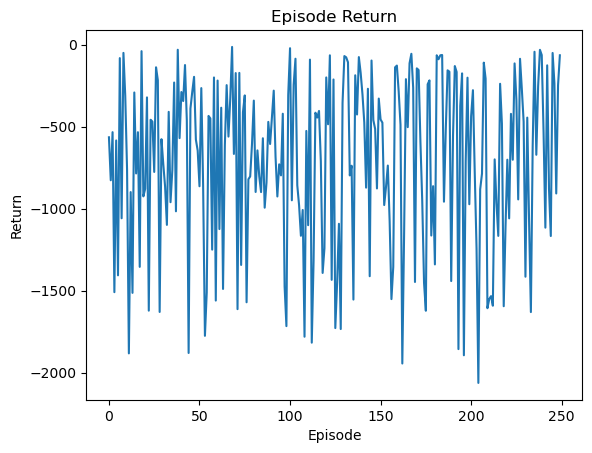

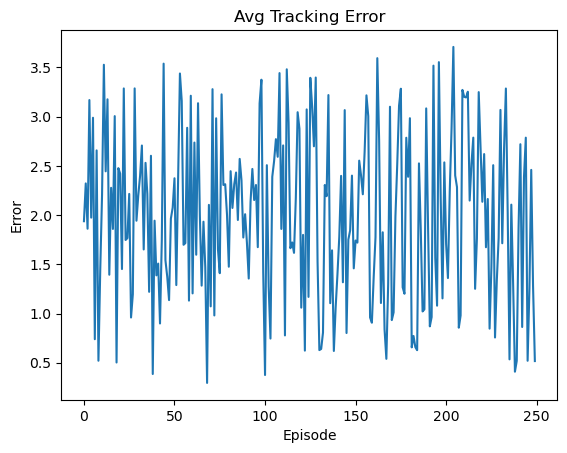

In [50]:
import matplotlib.pyplot as plt

plt.plot(returns)
plt.title("Episode Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

plt.plot(avg_err)
plt.title("Avg Tracking Error")
plt.xlabel("Episode")
plt.ylabel("Error")
plt.show()